In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Red Wine Quality Classification

## Introduction
This part of the project is set to explore the application of 2 classification models - logistic regression and support vector machine (SVM), on the Red Wine Quality dataset on Kaggle, which contains data related to red variants of the Portuguese "Vinho Verde" wine. https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

The goal is to classify red wine as good (quality $\geq 7$) or bad (quality $\leq 6$).

## Data Preprocessing & EDA

This is to discover and address null values, invalid values, wrong data types and outliers. We would also visualize initial relationships between features.

In [2]:
df_wine = pd.read_csv('winequality-red.csv')
df_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df_wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [5]:
# 2. Binary Target Transformation
# Create the new binary target column
df_wine['is_good'] = df_wine['quality'].apply(lambda x: 1 if x >= 7 else 0)

# Drop the original 'quality' column
df_wine.drop('quality', axis=1, inplace=True)

# 3. Check for Missing Values (This dataset rarely has them)
print("Missing Values:\n", df_wine.isnull().sum().sum())

Missing Values:
 0


In [6]:
df_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,is_good
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


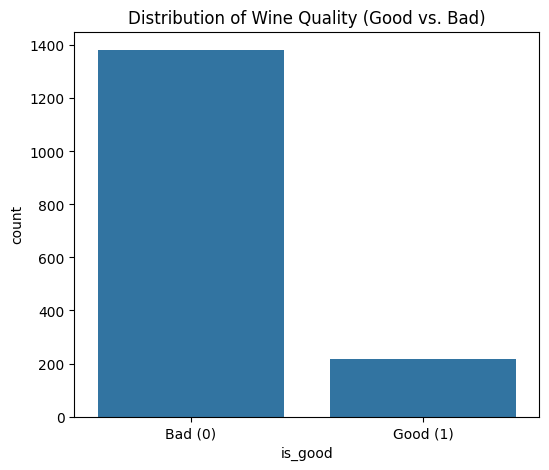

Percentage of Good Wine: 13.57%


In [7]:
plt.figure(figsize=(6, 5))
sns.countplot(x='is_good', data=df_wine)
plt.title('Distribution of Wine Quality (Good vs. Bad)')
plt.xticks([0, 1], ['Bad (0)', 'Good (1)'])
plt.show()

# Calculate the imbalance percentage
good_count = df_wine['is_good'].sum()
total_count = df_wine.shape[0]
imbalance = good_count / total_count
print(f"Percentage of Good Wine: {imbalance*100:.2f}%")

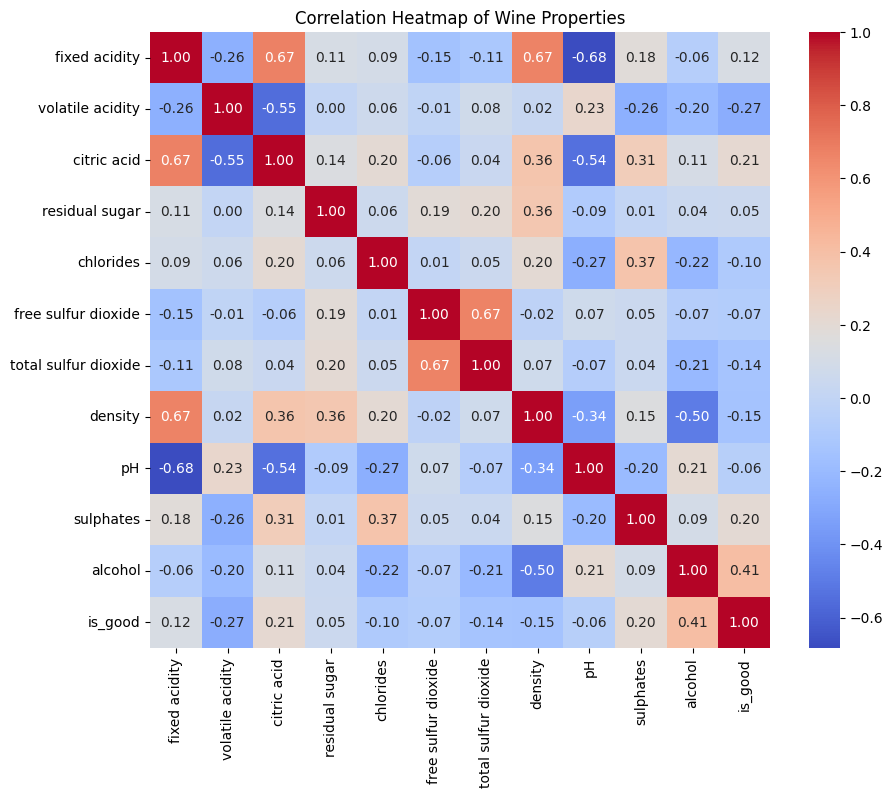


Top Correlations with 'is_good' (Target):
 is_good        1.000000
alcohol        0.407315
citric acid    0.214716
sulphates      0.199485
Name: is_good, dtype: float64


In [8]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_wine.corr()
# Focus on the correlation with the target 'is_good'
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Wine Properties')
plt.show()

print("\nTop Correlations with 'is_good' (Target):\n", 
      correlation_matrix['is_good'].sort_values(ascending=False).head(4))

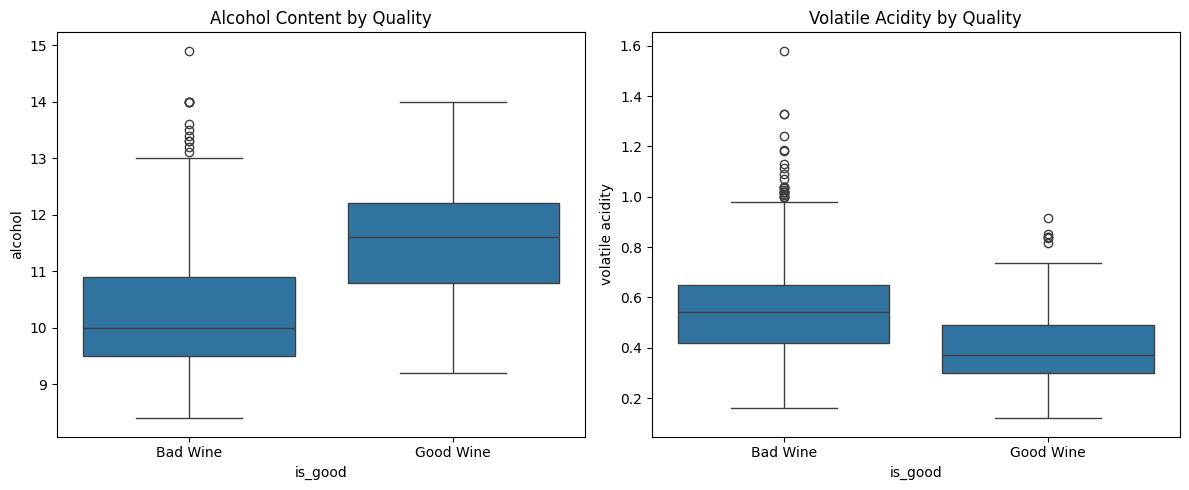

In [9]:
# Compare the distribution of the two most correlated features
plt.figure(figsize=(12, 5))

# Plot 1: Alcohol
plt.subplot(1, 2, 1)
sns.boxplot(x='is_good', y='alcohol', data=df_wine)
plt.title('Alcohol Content by Quality')
plt.xticks([0, 1], ['Bad Wine', 'Good Wine'])

# Plot 2: Volatile Acidity
plt.subplot(1, 2, 2)
sns.boxplot(x='is_good', y='volatile acidity', data=df_wine)
plt.title('Volatile Acidity by Quality')
plt.xticks([0, 1], ['Bad Wine', 'Good Wine'])

plt.tight_layout()
plt.show()

## Model Implementation and Evaluation

In [15]:
# Separate features (X) and target (y)
X = df_wine.drop('is_good', axis=1)
y = df_wine['is_good']

# Force data to be a contiguous float64 numpy array
X = np.ascontiguousarray(X, dtype=np.float64)

# Split the raw data first to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42,
    # Stratify is crucial here due to class imbalance. 
    # It ensures the test set has the same proportion of 'Good' wines as the training set. 
    stratify=y 
)

print(f"Train set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Train set size: 1199 samples
Test set size: 400 samples


In [11]:
# ------- For imputation and scaling -------


# 1. Identify column types
# Even though all our columns are numeric, we define them here. 
# If you had categorical columns (like 'Color'), you would put them in a cat_cols list.
# numeric_cols = X.columns.tolist()

# # 2. Create the numerical preprocessing steps
# # This replaces missing values with the median, THEN scales the data
# numeric_transformer = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', StandardScaler())
# ])

# # (Optional) If you had categorical columns, the transformer would look like this:
# # categorical_transformer = Pipeline(steps=[
# #     ('imputer', SimpleImputer(strategy='most_frequent')),
# #     ('onehot', OneHotEncoder(handle_unknown='ignore'))
# # ])

# # 3. Combine transformers using ColumnTransformer
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', numeric_transformer, numeric_cols),
#         # ('cat', categorical_transformer, cat_cols) # Uncomment if you had categorical data
#     ])

# # 4. Build the final Pipelines
# log_reg_pipeline = Pipeline([
#     ('preprocessor', preprocessor),
#     ('log_reg', LogisticRegression(random_state=42, solver='liblinear'))
# ])

# svc_pipeline = Pipeline([
#     ('preprocessor', preprocessor),
#     ('svc', SVC(kernel='rbf', random_state=42, class_weight='balanced'))
# ])

# Now when you call .fit(), it will impute, scale, and train all at once!
# log_reg_pipeline.fit(X_train, y_train)

In [16]:
# Logistic Regression Pipeline
# log_reg_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('log_reg', LogisticRegression(random_state=42, solver='liblinear'))
# ])

# log_reg_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     # Changed solver to 'lbfgs' and increased max_iter to ensure it converges
#     ('log_reg', LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000))
# ])

# # Support Vector Machine Pipeline
# svc_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('svc', SVC(kernel='rbf', random_state=42, class_weight='balanced'))
# ])

In [19]:
# Build pipelines (This bundles the Scaler + Model together)

# Build the SVM Pipeline (Uses C++ libsvm under the hood, usually avoids the bug)
# Class weight is critical due to imbalance (10-15% 'Good' wine). 
# It tells the model to pay more attention to the minority class.
svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', random_state=42, class_weight='balanced'))
])

# Build a Random Forest Pipeline (Bypasses matrix multiplication entirely)
rf_pipeline = Pipeline([
    # Random Forests technically don't need scaling, but keeping it in the pipeline 
    # ensures your API has a consistent preprocessing step for all models!
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

In [20]:
# Train the models
# (The pipeline automatically scales X_train, then trains the model)
print("Training SVM...")
svc_pipeline.fit(X_train, y_train)

print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)

Training SVM...
Training Random Forest...


Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [21]:
# Predict (The pipeline automatically scales X_test using the rules it learned from X_train)
y_pred_svc = svc_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

### Model Evaluation

In [22]:
accuracy_svc = accuracy_score(y_test, y_pred_svc)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("\n--- Initial Accuracy Check (Caution advised due to imbalance) ---")
print(f"SVM Accuracy: {accuracy_svc:.4f}")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")


--- Initial Accuracy Check (Caution advised due to imbalance) ---
SVM Accuracy: 0.8325
Random Forest Accuracy: 0.9325


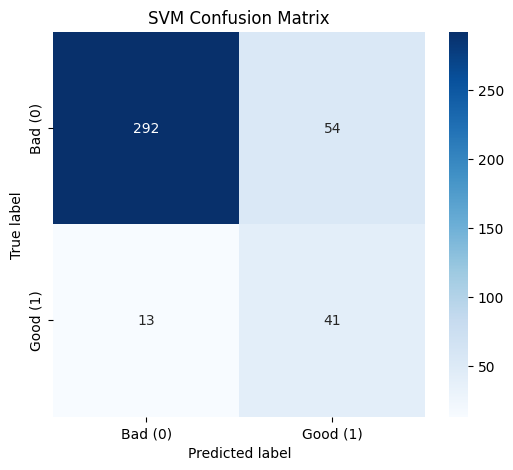

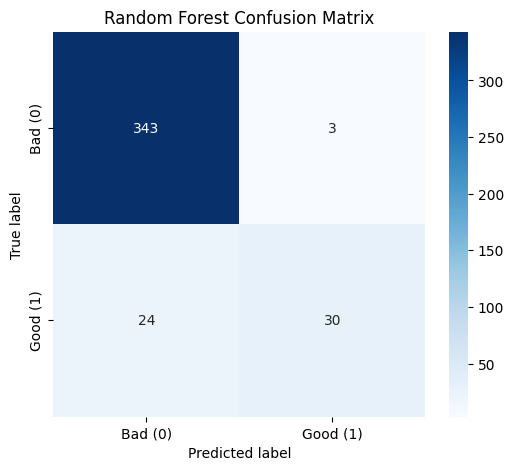

In [23]:
# Function to plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Bad (0)', 'Good (1)'], 
                yticklabels=['Bad (0)', 'Good (1)'])
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# Plot for Support Vector Machine
plot_confusion_matrix(y_test, y_pred_svc, 'SVM Confusion Matrix')


# Plot for Random Forest
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix')

In [24]:
print("\n--- SVM (Balanced) Classification Report ---")
print(classification_report(y_test, y_pred_svc, target_names=['Bad (0)', 'Good (1)']))

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['Bad (0)', 'Good (1)']))


--- SVM Classification Report ---
              precision    recall  f1-score   support

     Bad (0)       0.96      0.84      0.90       346
    Good (1)       0.43      0.76      0.55        54

    accuracy                           0.83       400
   macro avg       0.69      0.80      0.72       400
weighted avg       0.89      0.83      0.85       400


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

     Bad (0)       0.93      0.99      0.96       346
    Good (1)       0.91      0.56      0.69        54

    accuracy                           0.93       400
   macro avg       0.92      0.77      0.83       400
weighted avg       0.93      0.93      0.93       400



Recall (Sensitivity) - Ability to find all positive samples (TP/(TP+FN)): Due to class_weight='balanced', the SVM model is better at this, as it successfully flagged 76% of the good wines. The Random Forest was more cautious and only found 56% of them.

Precision - Accuracy of positive predictions (TP/(TP+FP)): This measures how often the model is correct when it claims a wine is "Good." The Random Forest is the clear winner here. When it says a wine is good, it is right 91% of the time. The SVM model is only right 43% of the time, meaning it frequently confuses bad wine for good wine.

F1-Score - The harmonic mean of Precision and Recall: The best single measure for imbalanced data: Because our dataset is mostly bad wine, we need a metric that balances finding the good wine (Recall) without making too many mistakes (Precision). The Random Forest achieves a much better overall balance for the "Good" category (a score of 0.69 compared to the SVM's 0.55).

In [25]:
# Save the best model pipeline
# After reviewing the accuracy metrics, we save the chosen model
model_filename = 'wine_quality_pipeline.pkl'
joblib.dump(rf_pipeline, model_filename)

print(f"\nSuccess! Model and Scaler bundled and saved as: {model_filename}")


Success! Model and Scaler bundled and saved as: wine_quality_pipeline.pkl


## Conclusion

The Random Forest model is the best choice for this project.

Even though the SVM model is better at finding the highest total number of good wines, it is not very efficient. It labels far too many average or bad wines as "Good." The Random Forest model is much more precise and trustworthy when making its predictions.

In a real-world business scenario, this difference is huge. While a wine seller wants to identify all their premium bottles, accidentally selling a bad bottle to a customer who paid for a "premium" product will ruin the brand's reputation. The Random Forest model provides the most reliable way to discover high-quality inventory while keeping strict quality control.

## References

https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

https://gemini.google.com - Google Gemini was used for project structure, code generation and statistical clarification

All code libraries are listed at the top of the page